In [2]:
# Dig deeper into the folder structure
import os

path = '/kaggle/input/datasets'
if os.path.exists(path):
    for dirpath, dirnames, filenames in os.walk('/kaggle/input'):
        # Only print first 3 levels to keep output manageable
        level = dirpath.replace('/kaggle/input', '').count(os.sep)
        if level < 3:
            indent = '  ' * level
            print(f'{indent}{os.path.basename(dirpath)}/')
            for f in filenames:
                print(f'{indent}  {f}')

input/
  datasets/
    kmader/


In [3]:
# Find the exact path to the metadata CSV
import os
import subprocess
result = subprocess.run(['find', '/kaggle/input', '-name', 'HAM10000_metadata.csv'], 
                       capture_output=True, text=True, timeout=10)
print("Metadata CSV found at:")
print(result.stdout)

# Also find image directories
result2 = subprocess.run(['find', '/kaggle/input', '-type', 'd', '-name', 'HAM10000_images_part_1'], 
                        capture_output=True, text=True, timeout=10)
print("\nImage directory found at:")
print(result2.stdout)

Metadata CSV found at:
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv


Image directory found at:
/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1



In [4]:
# ============================================================
# CELL 1: CONFIG + ALL SOURCE MODULES (FIXED v2)
# ============================================================

import logging, os, random, subprocess, sys, time
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, f1_score)
from sklearn.model_selection import StratifiedShuffleSplit
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ All imports successful")

# === CONFIG ===
IS_KAGGLE = Path("/kaggle/input").exists()
SEED = 42

def _find_dataset_root():
    candidates = [
        Path("/kaggle/input/skin-cancer-mnist-ham10000"),
        Path("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"),
        Path("/kaggle/input/datasets/anushapundir/skin-cancer-mnist-ham10000"),
    ]
    if Path("/kaggle/input").exists():
        try:
            result = subprocess.run(
                ["find", "/kaggle/input", "-name", "HAM10000_metadata.csv", "-maxdepth", "5"],
                capture_output=True, text=True, timeout=15)
            for line in result.stdout.strip().split("\n"):
                if line: candidates.insert(0, Path(line).parent)
        except: pass
    for c in candidates:
        if c.exists() and (c / "HAM10000_metadata.csv").exists(): return c
    return Path("/kaggle/input/skin-cancer-mnist-ham10000")

DATASET_ROOT = _find_dataset_root() if IS_KAGGLE else Path("./data/skin-cancer-mnist-ham10000")
IMAGE_DIRS = [DATASET_ROOT / "HAM10000_images_part_1", DATASET_ROOT / "HAM10000_images_part_2"]
METADATA_CSV = DATASET_ROOT / "HAM10000_metadata.csv"
ARTIFACTS_ROOT = Path("/kaggle/working/artifacts") if IS_KAGGLE else Path("./artifacts")
CLASSIFIER_DIR = ARTIFACTS_ROOT / "classifier"
BEST_MODEL_PATH = CLASSIFIER_DIR / "best_model.pth"
TRAINING_CURVES_PATH = CLASSIFIER_DIR / "training_curves.png"
CONFUSION_MATRIX_PATH = CLASSIFIER_DIR / "confusion_matrix.png"
CLASSIFICATION_REPORT_PATH = CLASSIFIER_DIR / "classification_report.txt"
TEST_SPLIT_CSV_PATH = CLASSIFIER_DIR / "test_split.csv"
TRAINING_LOG_PATH = CLASSIFIER_DIR / "training_log.csv"

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
NUM_CLASSES = len(CLASS_NAMES)

TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
BATCH_SIZE, NUM_WORKERS, PIN_MEMORY = 32, 2, True

# --- FIXED HYPERPARAMETERS ---
STAGE1_EPOCHS = 15       # was 10 → more time for head to converge
STAGE1_LR     = 1e-3

STAGE2_EPOCHS      = 30  # was 25 → more time for fine-tuning
STAGE2_LR_BACKBONE = 5e-5  # was 1e-5 → medical images need more adaptation
STAGE2_LR_HEAD     = 5e-4  # was 1e-4 → head also needs faster learning

LABEL_SMOOTHING = 0.1
EARLY_STOP_PATIENCE = 10  # was 7 → more patience

print(f"✓ Config loaded — Dataset: {DATASET_ROOT}")
print(f"  CSV exists: {METADATA_CSV.exists()}, Img dirs exist: {IMAGE_DIRS[0].exists()}, {IMAGE_DIRS[1].exists()}")

✓ All imports successful
✓ Config loaded — Dataset: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
  CSV exists: True, Img dirs exist: True, True


In [5]:
# ============================================================
# CELL 2: ALL FUNCTIONS (FIXED v2)
# ============================================================

logger = logging.getLogger("dermwise")
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)-7s | %(message)s",
                    datefmt="%H:%M:%S", handlers=[logging.StreamHandler(sys.stdout)])

# === DATA UTILS ===

def load_metadata(csv_path=METADATA_CSV, image_dirs=IMAGE_DIRS):
    logger.info(f"Loading metadata from: {csv_path}")
    df = pd.read_csv(csv_path)
    logger.info(f"  Total rows: {len(df)}")
    image_path_lookup = {}
    for img_dir in image_dirs:
        if not img_dir.exists(): continue
        for img_file in img_dir.glob("*.jpg"):
            image_path_lookup[img_file.stem] = img_file
    logger.info(f"  Found {len(image_path_lookup)} images")
    df["image_path"] = df["image_id"].map(image_path_lookup)
    missing = df["image_path"].isna().sum()
    if missing > 0:
        df = df.dropna(subset=["image_path"]).reset_index(drop=True)
    df["image_path"] = df["image_path"].astype(str)
    label_map = {name: idx for idx, name in enumerate(CLASS_NAMES)}
    df["label"] = df["dx"].map(label_map)
    logger.info("  Class distribution:")
    for cls in CLASS_NAMES:
        cnt = (df["dx"] == cls).sum()
        logger.info(f"    {cls:>6s}: {cnt:5d}  ({100*cnt/len(df):5.1f}%)")
    return df

def split_by_lesion_id(df, train_r=TRAIN_RATIO, val_r=VAL_RATIO, test_r=TEST_RATIO, seed=SEED):
    lesion_df = df.groupby("lesion_id")["dx"].first().reset_index()
    logger.info(f"Splitting {len(lesion_df)} unique lesions...")
    sp1 = StratifiedShuffleSplit(n_splits=1, test_size=test_r, random_state=seed)
    tv_idx, te_idx = next(sp1.split(lesion_df, lesion_df["dx"]))
    tv_les, te_les = lesion_df.iloc[tv_idx], lesion_df.iloc[te_idx]
    rel_val = val_r / (train_r + val_r)
    sp2 = StratifiedShuffleSplit(n_splits=1, test_size=rel_val, random_state=seed)
    tr_idx, va_idx = next(sp2.split(tv_les, tv_les["dx"]))
    tr_ids = set(tv_les.iloc[tr_idx]["lesion_id"])
    va_ids = set(tv_les.iloc[va_idx]["lesion_id"])
    te_ids = set(te_les["lesion_id"])
    train_df = df[df["lesion_id"].isin(tr_ids)].reset_index(drop=True)
    val_df   = df[df["lesion_id"].isin(va_ids)].reset_index(drop=True)
    test_df  = df[df["lesion_id"].isin(te_ids)].reset_index(drop=True)
    for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        logger.info(f"  {name}: {len(d):5d} images ({100*len(d)/len(df):.1f}%)")
    assert tr_ids.isdisjoint(va_ids) and tr_ids.isdisjoint(te_ids) and va_ids.isdisjoint(te_ids)
    logger.info("  No data leakage confirmed.")
    return train_df, val_df, test_df

def get_transforms(mode="train"):
    if mode == "train":
        # FIXED: Simpler augmentation — removed redundant RandomAffine + RandomResizedCrop
        # Using Resize instead to avoid distribution shift between train/val
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.5),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.05),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

class HAM10000Dataset(Dataset):
    def __init__(self, df, transform):
        self.image_paths = df["image_path"].values
        self.labels = df["label"].values
        self.transform = transform
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        return self.transform(img), int(self.labels[idx])

def build_weighted_sampler(labels):
    counts = np.bincount(labels, minlength=NUM_CLASSES)
    weights = 1.0 / counts.astype(np.float64)
    sample_w = torch.tensor([weights[l] for l in labels], dtype=torch.float64)
    return WeightedRandomSampler(sample_w, num_samples=len(sample_w), replacement=True)

def build_dataloaders(train_df, val_df, test_df):
    train_ds = HAM10000Dataset(train_df, get_transforms("train"))
    val_ds   = HAM10000Dataset(val_df,   get_transforms("val"))
    test_ds  = HAM10000Dataset(test_df,  get_transforms("test"))
    sampler = build_weighted_sampler(train_df["label"].values)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                              num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
    logger.info(f"DataLoaders: {len(train_loader)} train, {len(val_loader)} val, {len(test_loader)} test")
    return train_loader, val_loader, test_loader

# === MODEL UTILS ===

def build_model(num_classes=NUM_CLASSES, pretrained=True):
    if pretrained:
        logger.info("Loading EfficientNet-B0 (ImageNet pretrained)...")
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    else:
        model = efficientnet_b0(weights=None)
    in_feat = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_feat, num_classes)
    logger.info(f"  Head: Linear({in_feat}, {num_classes}), Total params: {sum(p.numel() for p in model.parameters()):,}")
    return model

def freeze_backbone(model):
    for p in model.features.parameters(): p.requires_grad = False
    logger.info(f"Backbone FROZEN — trainable: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

def unfreeze_backbone(model):
    for p in model.parameters(): p.requires_grad = True
    logger.info(f"Backbone UNFROZEN — all {sum(p.numel() for p in model.parameters()):,} params trainable")

def get_optimizer(model, stage):
    if stage == 1:
        opt = Adam(model.classifier.parameters(), lr=STAGE1_LR, weight_decay=1e-4)
        logger.info(f"Stage 1 optimizer: Adam(classifier, lr={STAGE1_LR})")
    else:
        params = [{"params": model.features.parameters(), "lr": STAGE2_LR_BACKBONE},
                  {"params": model.classifier.parameters(), "lr": STAGE2_LR_HEAD}]
        opt = Adam(params, weight_decay=1e-4)
        logger.info(f"Stage 2 optimizer: backbone_lr={STAGE2_LR_BACKBONE}, head_lr={STAGE2_LR_HEAD}")
    return opt

def get_scheduler(optimizer, num_epochs, use_plateau=False):
    if use_plateau:
        sch = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-7)
        logger.info("Scheduler: ReduceLROnPlateau(max, factor=0.5, patience=3)")
    else:
        sch = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-7)
        logger.info(f"Scheduler: CosineAnnealingLR(T_max={num_epochs})")
    return sch

# === METRICS ===

def compute_macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro", zero_division=0)

def compute_accuracy(y_true, y_pred):
    return accuracy_score(y_true, y_pred)

def print_classification_report_fn(y_true, y_pred, save_path=CLASSIFICATION_REPORT_PATH):
    report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0)
    logger.info(f"\n{'='*60}\nClassification Report\n{'='*60}\n{report}")
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    with open(save_path, "w") as f:
        f.write("Dermwise GenAI — Classification Report\n" + "="*60 + "\n\n" + report)
    return report

def plot_confusion_matrix(y_true, y_pred, save_path=CONFUSION_MATRIX_PATH, normalize=True):
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm_d = cm.astype(np.float64) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
        fmt = ".2f"
    else:
        cm_d, fmt = cm, "d"
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm_d, annot=True, fmt=fmt, cmap="Blues", xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES, square=True, linewidths=0.5, ax=ax)
    ax.set_xlabel("Predicted", fontsize=13); ax.set_ylabel("True", fontsize=13)
    ax.set_title(f"Confusion Matrix {'(Norm)' if normalize else '(Counts)'}", fontsize=15)
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.close(fig)
    logger.info(f"Confusion matrix → {save_path}")

# === TRAINING ===

class EarlyStopping:
    def __init__(self, patience=EARLY_STOP_PATIENCE, min_delta=0.001, checkpoint_path=BEST_MODEL_PATH):
        self.patience, self.min_delta = patience, min_delta
        self.checkpoint_path = Path(checkpoint_path)
        self.best_f1, self.counter, self.best_epoch = -1.0, 0, -1
    def __call__(self, val_f1, model, epoch):
        if val_f1 > self.best_f1 + self.min_delta:
            self.best_f1, self.best_epoch, self.counter = val_f1, epoch, 0
            self.checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), self.checkpoint_path)
            logger.info(f"  ★ New best F1: {val_f1:.4f} — saved")
            return False
        self.counter += 1
        logger.info(f"  No improvement {self.counter}/{self.patience} (best: {self.best_f1:.4f})")
        return self.counter >= self.patience

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for images, labels in tqdm(loader, desc="  Train", leave=False):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running_loss += loss.item() * images.size(0)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / len(loader.dataset), np.array(all_preds), np.array(all_labels)

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []
    for images, labels in tqdm(loader, desc="  Val  ", leave=False):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return running_loss / len(loader.dataset), np.array(all_preds), np.array(all_labels)

def run_training(model, train_loader, val_loader, criterion, optimizer, scheduler,
                 device, num_epochs, early_stopper, stage_name="Stage"):
    history = {"train_loss":[], "val_loss":[], "train_f1":[], "val_f1":[], "train_acc":[], "val_acc":[]}
    logger.info(f"\n{'='*60}\n{stage_name} — {num_epochs} max epochs\n{'='*60}")
    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        tr_loss, tr_pred, tr_lbl = train_one_epoch(model, train_loader, criterion, optimizer, device)
        tr_f1, tr_acc = compute_macro_f1(tr_lbl, tr_pred), compute_accuracy(tr_lbl, tr_pred)
        va_loss, va_pred, va_lbl = validate(model, val_loader, criterion, device)
        va_f1, va_acc = compute_macro_f1(va_lbl, va_pred), compute_accuracy(va_lbl, va_pred)
        for k, v in [("train_loss",tr_loss),("val_loss",va_loss),("train_f1",tr_f1),
                      ("val_f1",va_f1),("train_acc",tr_acc),("val_acc",va_acc)]:
            history[k].append(v)
        lrs = ", ".join([f"{pg['lr']:.2e}" for pg in optimizer.param_groups])
        logger.info(f"[{stage_name}] Ep {epoch:02d}/{num_epochs} | "
                    f"TrL:{tr_loss:.4f} VaL:{va_loss:.4f} | TrF1:{tr_f1:.4f} VaF1:{va_f1:.4f} | "
                    f"TrAcc:{tr_acc:.4f} VaAcc:{va_acc:.4f} | LR:[{lrs}] | {time.time()-t0:.1f}s")
        if early_stopper(va_f1, model, epoch):
            logger.info(f"Early stopping at epoch {epoch}."); break
        # Step scheduler — ReduceLROnPlateau needs the metric value
        if isinstance(scheduler, ReduceLROnPlateau):
            scheduler.step(va_f1)
        else:
            scheduler.step()
    logger.info(f"{stage_name} done. Best F1: {early_stopper.best_f1:.4f} @ epoch {early_stopper.best_epoch}")
    return history

def plot_training_curves(h1, h2, save_path=TRAINING_CURVES_PATH):
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    s1 = len(h1["train_loss"]); epochs = list(range(1, s1 + len(h2["train_loss"]) + 1))
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(epochs, h1["train_loss"]+h2["train_loss"], "b-", label="Train Loss")
    axes[0].plot(epochs, h1["val_loss"]+h2["val_loss"], "r-", label="Val Loss")
    axes[0].axvline(s1+0.5, color="gray", ls="--", alpha=0.7, label="Stage1→2")
    axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, h1["train_f1"]+h2["train_f1"], "b-", label="Train F1")
    axes[1].plot(epochs, h1["val_f1"]+h2["val_f1"], "r-", label="Val F1")
    axes[1].axvline(s1+0.5, color="gray", ls="--", alpha=0.7, label="Stage1→2")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.close(fig)
    logger.info(f"Training curves → {save_path}")

print("✓ All functions defined")


✓ All functions defined


In [6]:
# ============================================================
# CELL 3: TRAIN (FIXED v2) — ~40-50 min
# ============================================================
# KEY FIXES:
# 1. NO class weights in loss → only WeightedRandomSampler handles imbalance
# 2. Stage 1: 15 epochs (was 10) with CosineAnnealing
# 3. Stage 2: backbone LR=5e-5 (was 1e-5), head LR=5e-4 (was 1e-4)
# 4. Stage 2 uses ReduceLROnPlateau (adapts to actual performance)
# 5. Patience=10, simpler augmentation
# ============================================================

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if torch.cuda.is_available() else ""))
CLASSIFIER_DIR.mkdir(parents=True, exist_ok=True)

# --- Data ---
df = load_metadata()
train_df, val_df, test_df = split_by_lesion_id(df)
test_df.to_csv(TEST_SPLIT_CSV_PATH, index=False)
train_loader, val_loader, test_loader = build_dataloaders(train_df, val_df, test_df)

# --- Model ---
model = build_model().to(device)

# --- FIX #1: NO class weights in loss! ---
# The WeightedRandomSampler already balances class representation in batches.
# Adding class weights on top OVER-CORRECTS and causes the train-val gap.
# Just use plain CrossEntropyLoss with label smoothing.
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
logger.info(f"Loss: CrossEntropyLoss(NO class weights, smoothing={LABEL_SMOOTHING})")

# ===================== STAGE 1 =====================
logger.info("\n" + "="*70 + "\nSTAGE 1: Head only (backbone frozen)\n" + "="*70)
freeze_backbone(model)
opt1 = get_optimizer(model, 1)
sch1 = get_scheduler(opt1, STAGE1_EPOCHS, use_plateau=False)
es1 = EarlyStopping(patience=EARLY_STOP_PATIENCE)
h1 = run_training(model, train_loader, val_loader, criterion, opt1, sch1, device, STAGE1_EPOCHS, es1, "Stage 1")

# ===================== STAGE 2 =====================
logger.info("\n" + "="*70 + "\nSTAGE 2: Full fine-tune (backbone unfrozen)\n" + "="*70)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
unfreeze_backbone(model)
opt2 = get_optimizer(model, 2)
sch2 = get_scheduler(opt2, STAGE2_EPOCHS, use_plateau=True)  # ReduceLROnPlateau for Stage 2
es2 = EarlyStopping(patience=EARLY_STOP_PATIENCE)
es2.best_f1 = es1.best_f1; es2.best_epoch = es1.best_epoch
h2 = run_training(model, train_loader, val_loader, criterion, opt2, sch2, device, STAGE2_EPOCHS, es2, "Stage 2")

# ===================== SAVE =====================
plot_training_curves(h1, h2)
s1n, s2n = len(h1["train_loss"]), len(h2["train_loss"])
pd.DataFrame({
    "epoch": list(range(1, s1n+s2n+1)), "stage": ["s1"]*s1n + ["s2"]*s2n,
    "train_loss": h1["train_loss"]+h2["train_loss"], "val_loss": h1["val_loss"]+h2["val_loss"],
    "train_f1": h1["train_f1"]+h2["train_f1"], "val_f1": h1["val_f1"]+h2["val_f1"],
    "train_acc": h1["train_acc"]+h2["train_acc"], "val_acc": h1["val_acc"]+h2["val_acc"],
}).to_csv(TRAINING_LOG_PATH, index=False)

best_f1 = max(es1.best_f1, es2.best_f1)
logger.info(f"\n{'='*70}\nTRAINING COMPLETE — Best Val Macro F1: {best_f1:.4f}\n{'='*70}")

14:49:46 | INFO    | Device: cuda (Tesla T4)
14:49:46 | INFO    | Loading metadata from: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv
14:49:46 | INFO    |   Total rows: 10015
14:49:46 | INFO    |   Found 10015 images
14:49:46 | INFO    |   Class distribution:
14:49:46 | INFO    |      akiec:   327  (  3.3%)
14:49:46 | INFO    |        bcc:   514  (  5.1%)
14:49:46 | INFO    |        bkl:  1099  ( 11.0%)
14:49:46 | INFO    |         df:   115  (  1.1%)
14:49:46 | INFO    |        mel:  1113  ( 11.1%)
14:49:46 | INFO    |         nv:  6705  ( 66.9%)
14:49:46 | INFO    |       vasc:   142  (  1.4%)
14:49:46 | INFO    | Splitting 7470 unique lesions...
14:49:46 | INFO    |   Train:  7054 images (70.4%)
14:49:46 | INFO    |   Val:  1464 images (14.6%)
14:49:46 | INFO    |   Test:  1497 images (14.9%)
14:49:46 | INFO    |   No data leakage confirmed.
14:49:47 | INFO    | DataLoaders: 220 train, 46 val, 47 test
14:49:47 | INFO    | Loading EfficientNet-B0 (Im

100%|██████████| 20.5M/20.5M [00:00<00:00, 135MB/s] 


14:49:47 | INFO    |   Head: Linear(1280, 7), Total params: 4,016,515
14:49:47 | INFO    | Loss: CrossEntropyLoss(NO class weights, smoothing=0.1)
14:49:47 | INFO    | 
STAGE 1: Head only (backbone frozen)
14:49:47 | INFO    | Backbone FROZEN — trainable: 8,967
14:49:47 | INFO    | Stage 1 optimizer: Adam(classifier, lr=0.001)
14:49:47 | INFO    | Scheduler: CosineAnnealingLR(T_max=15)
14:49:47 | INFO    | 
Stage 1 — 15 max epochs


14:51:12 | INFO    | [Stage 1] Ep 01/15 | TrL:1.4707 VaL:1.3004 | TrF1:0.5168 VaF1:0.4483 | TrAcc:0.5183 VaAcc:0.6107 | LR:[1.00e-03] | 85.0s
14:51:12 | INFO    |   ★ New best F1: 0.4483 — saved


14:52:28 | INFO    | [Stage 1] Ep 02/15 | TrL:1.2682 VaL:1.2849 | TrF1:0.6097 VaF1:0.4611 | TrAcc:0.6145 VaAcc:0.6189 | LR:[9.89e-04] | 75.3s
14:52:28 | INFO    |   ★ New best F1: 0.4611 — saved


...

15:41:11 | INFO    | [Stage 2] Ep 25/30 | TrL:0.5665 VaL:0.8245 | TrF1:0.9676 VaF1:0.6885 | TrAcc:0.9675 VaAcc:0.8197 | LR:[1.25e-05, 1.25e-04] | 77.4s
15:41:11 | INFO    |   No improvement 7/10 (best: 0.7398)


15:42:29 | INFO    | [Stage 2] Ep 26/30 | TrL:0.5684 VaL:0.8366 | TrF1:0.9639 VaF1:0.6903 | TrAcc:0.9641 VaAcc:0.8190 | LR:[1.25e-05, 1.25e-04] | 78.0s
15:42:29 | INFO    |   No improvement 8/10 (best: 0.7398)


15:43:47 | INFO    | [Stage 2] Ep 27/30 | TrL:0.5689 VaL:0.8168 | TrF1:0.9642 VaF1:0.6937 | TrAcc:0.9643 VaAcc:0.8217 | LR:[6.25e-06, 6.25e-05] | 77.9s
15:43:47 | INFO    |   No improvement 9/10 (best: 0.7398)


15:45:05 | INFO    | [Stage 2] Ep 28/30 | TrL:0.5641 VaL:0.8142 | TrF1:0.9684 VaF1:0.6930 | TrAcc:0.9679 VaAcc:0.8258 | LR:[6.25e-06, 6.25e-05] | 78.2s
15:45:05 | INFO    |   No improvement 10/10 (best: 0.7398)
15:45:05 | INFO    | Early stopping at epoch 28.
15:45:05 | INFO    | Stage 2 done. Best F1: 0.7398 @ epoch 18


15:45:06 | INFO    | Training curves → /kaggle/working/artifacts/classifier/training_curves.png
15:45:06 | INFO    | 
TRAINING COMPLETE — Best Val Macro F1: 0.7398


15:45:06 | INFO    | Loaded checkpoint: /kaggle/working/artifacts/classifier/best_model.pth
15:45:24 | INFO    | Val  Standard → F1: 0.7398 | Acc: 0.8299
15:45:24 | INFO    | Val  TTA      → F1: 0.7509 | Acc: 0.8361
15:45:48 | INFO    | Test  Standard → F1: 0.7055 | Acc: 0.8130
15:45:48 | INFO    | Test  TTA      → F1: 0.7033 | Acc: 0.8190
15:45:49 | INFO    | 
Best variant on Val: TTA

  Val Set — TTA — Classification Report
              precision    recall  f1-score   support

       akiec     0.5690    0.7674    0.6535        43
         bcc     0.6429    0.8750    0.7412        72
         bkl     0.7445    0.6108    0.6711       167
          df     0.9231    0.7059    0.8000        17
         mel     0.5535    0.7083    0.6214       168
          nv     0.9522    0.8985    0.9245       975
        vasc     0.8261    0.8636    0.8444        22

    accuracy                         0.8361      1464
   macro avg     0.7445    0.7756    0.7509      1464
weighted avg     0.8540    0

/tmp/ipykernel_55/3177506992.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


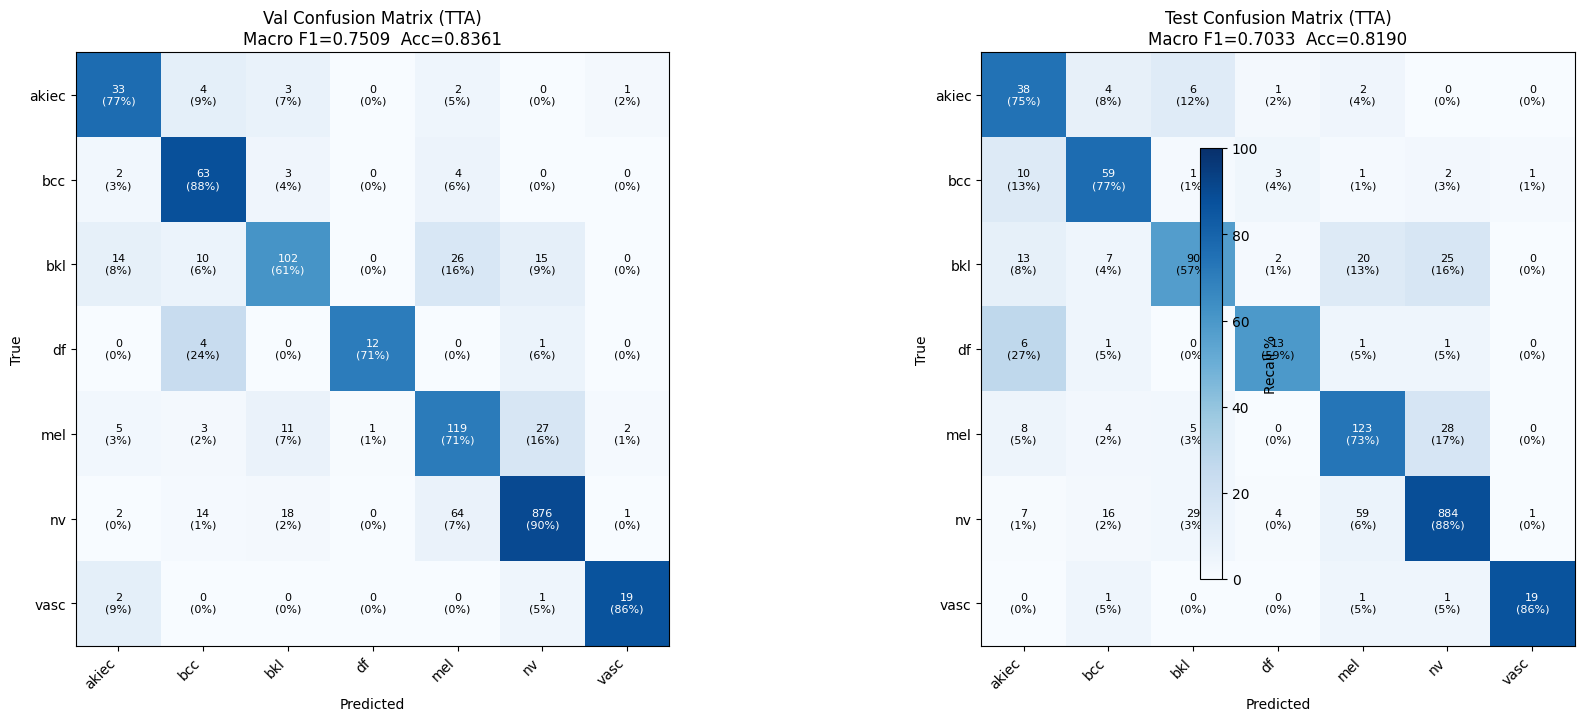

15:45:50 | INFO    | Confusion matrices saved to /kaggle/working/artifacts/classifier/confusion_matrices.png

  PER-CLASS SUMMARY (Test set)
Class     Support  Correct   Recall       F1
--------------------------------------------
akiec          51       38   0.7451   0.5714
bcc            77       59   0.7662   0.6982
bkl           157       90   0.5732   0.6250
df             22       13   0.5909   0.5778
mel           168      123   0.7321   0.6560
nv           1000      884   0.8840   0.9109
vasc           22       19   0.8636   0.8837
--------------------------------------------
MACRO                        0.7365   0.7033
15:45:50 | INFO    | Evaluation summary saved to /kaggle/working/artifacts/classifier/eval_summary.json

✅ FINAL: TTA → Val F1=0.7509 | Test F1=0.7033


In [7]:
# ============================================================
# CELL 4 — EVALUATION (v2 best checkpoint)
# ============================================================
import json, itertools
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
SAVE_DIR = "/kaggle/working/artifacts/classifier"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── TTA helper ──────────────────────────────────────────────
def predict_with_tta(model, dataloader, device):
    """4-fold flip TTA: original + h-flip + v-flip + both."""
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            # 4 augmentations
            p0 = torch.softmax(model(imgs), dim=1)
            p1 = torch.softmax(model(torch.flip(imgs, [3])), dim=1)   # h-flip
            p2 = torch.softmax(model(torch.flip(imgs, [2])), dim=1)   # v-flip
            p3 = torch.softmax(model(torch.flip(imgs, [2, 3])), dim=1) # both
            avg = (p0 + p1 + p2 + p3) / 4.0
            all_probs.append(avg.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)

# ── Standard prediction ────────────────────────────────────
def predict_standard(model, dataloader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            probs = torch.softmax(model(imgs), dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.vstack(all_probs), np.concatenate(all_labels)

# ── Load best checkpoint ───────────────────────────────────
ckpt_path = os.path.join(SAVE_DIR, "best_model.pth")
model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model.to(DEVICE)
model.eval()
logger.info(f"Loaded checkpoint: {ckpt_path}")

# ── Evaluate on VAL and TEST ───────────────────────────────
results = {}
for split_name, loader in [("Val", val_loader), ("Test", test_loader)]:
    # Standard
    probs_std, labels = predict_standard(model, loader, DEVICE)
    preds_std = probs_std.argmax(axis=1)
    f1_std = f1_score(labels, preds_std, average='macro')
    acc_std = accuracy_score(labels, preds_std)

    # TTA
    probs_tta, _ = predict_with_tta(model, loader, DEVICE)
    preds_tta = probs_tta.argmax(axis=1)
    f1_tta = f1_score(labels, preds_tta, average='macro')
    acc_tta = accuracy_score(labels, preds_tta)

    results[split_name] = {
        'std': {'f1': f1_std, 'acc': acc_std, 'preds': preds_std, 'labels': labels},
        'tta': {'f1': f1_tta, 'acc': acc_tta, 'preds': preds_tta, 'labels': labels},
    }
    logger.info(f"{split_name}  Standard → F1: {f1_std:.4f} | Acc: {acc_std:.4f}")
    logger.info(f"{split_name}  TTA      → F1: {f1_tta:.4f} | Acc: {acc_tta:.4f}")

# ── Pick best variant for final report ─────────────────────
best_variant = 'tta' if results['Val']['tta']['f1'] >= results['Val']['std']['f1'] else 'std'
variant_label = "TTA" if best_variant == 'tta' else "Standard"
logger.info(f"\nBest variant on Val: {variant_label}")

# ── Classification Report (Val + Test) ─────────────────────

for split_name in ["Val", "Test"]:
    r = results[split_name][best_variant]
    print(f"\n{'='*60}")
    print(f"  {split_name} Set — {variant_label} — Classification Report")
    print(f"{'='*60}")
    print(classification_report(r['labels'], r['preds'],
                                target_names=CLASS_NAMES, digits=4, zero_division=0))

# ── Confusion Matrices ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, split_name in zip(axes, ["Val", "Test"]):
    r = results[split_name][best_variant]
    cm = confusion_matrix(r['labels'], r['preds'])
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    im = ax.imshow(cm_pct, interpolation='nearest', cmap='Blues', vmin=0, vmax=100)
    ax.set_title(f"{split_name} Confusion Matrix ({variant_label})\n"
                 f"Macro F1={r['f1']:.4f}  Acc={r['acc']:.4f}", fontsize=12)
    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f"{cm[i,j]}\n({cm_pct[i,j]:.0f}%)",
                ha='center', va='center', fontsize=8,
                color='white' if cm_pct[i,j] > 60 else 'black')

plt.colorbar(im, ax=axes, shrink=0.8, label="Recall %")
plt.tight_layout()
cm_path = os.path.join(SAVE_DIR, "confusion_matrices.png")
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
logger.info(f"Confusion matrices saved to {cm_path}")

# ── Per-class summary ──────────────────────────────────────
print(f"\n{'='*60}")
print("  PER-CLASS SUMMARY (Test set)")
print(f"{'='*60}")
r_test = results['Test'][best_variant]
cm_test = confusion_matrix(r_test['labels'], r_test['preds'])
print(f"{'Class':<8} {'Support':>8} {'Correct':>8} {'Recall':>8} {'F1':>8}")
print("-" * 44)
report = classification_report(r_test['labels'], r_test['preds'],
                               target_names=CLASS_NAMES, output_dict=True, zero_division=0)
for cls in CLASS_NAMES:
    sup = int(report[cls]['support'])
    rec = report[cls]['recall']
    f1 = report[cls]['f1-score']
    correct = int(round(rec * sup))
    print(f"{cls:<8} {sup:>8} {correct:>8} {rec:>8.4f} {f1:>8.4f}")
print("-" * 44)
print(f"{'MACRO':<8} {'':<8} {'':<8} {report['macro avg']['recall']:>8.4f} {report['macro avg']['f1-score']:>8.4f}")

# ── Save summary JSON ─────────────────────────────────────
summary = {
    'best_variant': variant_label,
    'val_f1': results['Val'][best_variant]['f1'],
    'val_acc': results['Val'][best_variant]['acc'],
    'test_f1': results['Test'][best_variant]['f1'],
    'test_acc': results['Test'][best_variant]['acc'],
}
json_path = os.path.join(SAVE_DIR, "eval_summary.json")
with open(json_path, 'w') as f:
    json.dump(summary, f, indent=2)
logger.info(f"Evaluation summary saved to {json_path}")
print(f"\n✅ FINAL: {variant_label} → Val F1={summary['val_f1']:.4f} | Test F1={summary['test_f1']:.4f}")

In [8]:
# ============================================================
# CELL 5 — PHASE 2: Knowledge Base + FAISS RAG Pipeline
# ============================================================
# Installs: sentence-transformers, faiss-cpu
# Builds: dermatology knowledge base, embeddings, FAISS index, retrieval

!pip install -q sentence-transformers faiss-cpu

import os, json, logging, textwrap
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer

logger = logging.getLogger("DermWise")
if not logger.handlers:
    logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)-7s | %(message)s",
                        datefmt="%H:%M:%S")
    logger = logging.getLogger("DermWise")

RAG_DIR = "/kaggle/working/artifacts/rag"
os.makedirs(RAG_DIR, exist_ok=True)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DERMATOLOGY KNOWLEDGE BASE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Each entry: {"class": ..., "category": ..., "text": ...}
# Categories: overview, appearance, risk_factors, differential_diagnosis,
#             treatment, prognosis, when_to_refer

KNOWLEDGE_BASE = [
    # ── AKIEC (Actinic Keratoses / Bowen's Disease) ──────────
    {"class": "akiec", "category": "overview",
     "text": "Actinic keratosis (AK) is a precancerous skin lesion caused by cumulative ultraviolet radiation exposure. It appears on sun-exposed areas such as the face, scalp, ears, forearms, and dorsal hands. Bowen's disease (squamous cell carcinoma in situ) is a closely related condition where atypical keratinocytes involve the full thickness of the epidermis but have not invaded the dermis."},
    {"class": "akiec", "category": "appearance",
     "text": "Actinic keratoses typically present as rough, scaly, erythematous patches or papules measuring 2-6 mm. They may be skin-colored, pink, or red, and are often easier felt than seen due to their sandpaper-like texture. Bowen's disease presents as a well-defined, erythematous, scaly plaque that grows slowly. Pigmented variants can mimic melanoma."},
    {"class": "akiec", "category": "risk_factors",
     "text": "Major risk factors for actinic keratosis include fair skin (Fitzpatrick types I-II), chronic sun exposure, age over 50, male sex, immunosuppression (organ transplant recipients have 250x increased risk), and history of sunburns. Outdoor occupations and living at low latitudes increase risk significantly."},
    {"class": "akiec", "category": "differential_diagnosis",
     "text": "Differential diagnosis of actinic keratosis includes squamous cell carcinoma (invasive), seborrheic keratosis, superficial basal cell carcinoma, psoriasis, and eczema. Dermoscopy showing a strawberry pattern (pseudonetwork with white-to-yellow structureless areas and dotted/glomerular vessels) supports the diagnosis. Biopsy is needed if SCC invasion is suspected."},
    {"class": "akiec", "category": "treatment",
     "text": "Treatment options for actinic keratosis include cryotherapy with liquid nitrogen (most common, cure rate 75-98%), topical 5-fluorouracil cream (field therapy), topical imiquimod 5% cream (immune modulator), photodynamic therapy (PDT), and surgical excision. Bowen's disease is typically treated with excision, PDT, or topical 5-FU. Regular follow-up is essential as AK has a 5-10% risk of progression to SCC."},
    {"class": "akiec", "category": "prognosis",
     "text": "Individual actinic keratoses have a low annual risk of progression to squamous cell carcinoma (estimated 0.025-16% per lesion per year). However, patients often have multiple AKs and the field cancerization concept means the surrounding skin is also at risk. Early treatment has excellent outcomes. Bowen's disease has a 3-5% risk of progression to invasive SCC if untreated."},
    {"class": "akiec", "category": "when_to_refer",
     "text": "Refer to dermatology if actinic keratoses are numerous (>10), recurrent after treatment, hypertrophic or indurated (suspicion of SCC), or in immunosuppressed patients. Urgent referral is needed if there are signs of invasive SCC: rapid growth, ulceration, bleeding, pain, or induration beyond the visible margins."},

    # ── BCC (Basal Cell Carcinoma) ───────────────────────────
    {"class": "bcc", "category": "overview",
     "text": "Basal cell carcinoma (BCC) is the most common human cancer, arising from basal cells of the epidermis. It accounts for approximately 80% of non-melanoma skin cancers. BCC is locally invasive but very rarely metastasizes (<0.1%). Subtypes include nodular (most common, 60-80%), superficial (15-25%), morphoeic/infiltrative (5-10%), and pigmented variants."},
    {"class": "bcc", "category": "appearance",
     "text": "Nodular BCC presents as a pearly, translucent papule or nodule with telangiectasia (visible blood vessels) and a rolled border. It may ulcerate centrally (rodent ulcer). Superficial BCC appears as a thin, erythematous, scaly plaque, often on the trunk. Morphoeic BCC presents as a waxy, scar-like plaque with ill-defined borders. Pigmented BCC contains melanin and can mimic melanoma."},
    {"class": "bcc", "category": "risk_factors",
     "text": "Risk factors for BCC include cumulative and intermittent intense UV exposure, fair skin, age over 50, prior radiation therapy, chronic arsenic exposure, immunosuppression, genetic conditions (basal cell nevus syndrome/Gorlin syndrome), and prior history of BCC (36-50% risk of developing another within 5 years)."},
    {"class": "bcc", "category": "differential_diagnosis",
     "text": "Differential diagnosis includes squamous cell carcinoma, amelanotic melanoma, sebaceous hyperplasia, molluscum contagiosum, and dermal nevus. Dermoscopy of nodular BCC shows arborizing (tree-like) vessels, blue-gray ovoid nests, leaf-like structures, and spoke-wheel areas. Superficial BCC shows short fine telangiectasia, shiny white-red structureless areas, and small erosions."},
    {"class": "bcc", "category": "treatment",
     "text": "Treatment depends on subtype, size, and location. Options include surgical excision (standard treatment, 95%+ cure rate), Mohs micrographic surgery (for high-risk locations like face, recurrent tumors — 99% cure rate), curettage and electrodesiccation, cryotherapy (superficial BCC only), topical imiquimod or 5-FU (superficial BCC), PDT, and hedgehog pathway inhibitors (vismodegib) for advanced/inoperable cases."},
    {"class": "bcc", "category": "prognosis",
     "text": "BCC has an excellent prognosis when treated early. Five-year cure rates exceed 95% with appropriate surgical management. However, incomplete excision leads to recurrence in 33-39% of cases. Patients with one BCC have a significantly increased risk of subsequent BCCs and should have regular skin surveillance every 6-12 months."},
    {"class": "bcc", "category": "when_to_refer",
     "text": "Refer to dermatology or surgical oncology for any suspected BCC. Urgent referral for morphoeic/infiltrative subtypes, lesions >2cm, recurrent BCC, BCC in high-risk locations (periorbital, nasolabial fold, ear), and BCC in immunosuppressed patients. Mohs surgery referral for facial BCC in cosmetically sensitive areas."},

    # ── BKL (Benign Keratosis) ───────────────────────────────
    {"class": "bkl", "category": "overview",
     "text": "Benign keratoses encompass seborrheic keratosis, solar lentigo, and lichen planus-like keratosis. Seborrheic keratosis (SK) is the most common benign skin tumor in adults, affecting nearly 100% of individuals over age 50. These are epidermal growths with no malignant potential. Solar lentigines (liver spots) are benign pigmented macules from chronic sun exposure."},
    {"class": "bkl", "category": "appearance",
     "text": "Seborrheic keratoses appear as well-demarcated, waxy, stuck-on papules and plaques ranging from skin-colored to dark brown or black. They have a verrucous surface with horn cysts visible on dermoscopy. Solar lentigines are flat, uniformly tan-to-brown macules on sun-exposed skin. Lichen planus-like keratosis presents as a solitary, flat-to-slightly raised lesion that may be pink, red-brown, or gray, often representing a regressing SK."},
    {"class": "bkl", "category": "risk_factors",
     "text": "Seborrheic keratoses increase with age and may have a genetic predisposition (autosomal dominant pattern reported). Sun exposure is the primary risk factor for solar lentigines. Neither condition is caused by viral infection. The sign of Leser-Trélat (sudden eruption of multiple SKs) may rarely indicate internal malignancy, though this association is debated."},
    {"class": "bkl", "category": "differential_diagnosis",
     "text": "The main diagnostic challenge is distinguishing dark seborrheic keratoses from melanoma. Dermoscopy showing milia-like cysts, comedo-like openings, gyri and sulci pattern (brain-like appearance), and sharp demarcation confirms SK. Solar lentigo must be distinguished from lentigo maligna. If any doubt exists, biopsy is recommended to rule out melanoma."},
    {"class": "bkl", "category": "treatment",
     "text": "Benign keratoses generally require no treatment. If removal is desired for cosmetic reasons, irritation, or diagnostic uncertainty, options include cryotherapy (most common), shave excision, curettage, electrodesiccation, and laser therapy. Biopsy is recommended for any lesion with atypical features. Treatment of solar lentigines includes topical retinoids, chemical peels, and intense pulsed light."},
    {"class": "bkl", "category": "prognosis",
     "text": "Benign keratoses have an excellent prognosis with no risk of malignant transformation. They are purely cosmetic concerns. Seborrheic keratoses may increase in number over time. Solar lentigines indicate chronic sun damage and patients should be monitored for other UV-related skin changes including actinic keratoses and skin cancer."},
    {"class": "bkl", "category": "when_to_refer",
     "text": "Referral to dermatology is recommended when a benign keratosis cannot be confidently distinguished from melanoma or other skin cancers, especially for darkly pigmented lesions, lesions with irregular borders, or lesions that change rapidly. The Leser-Trélat sign warrants investigation for internal malignancy."},

    # ── DF (Dermatofibroma) ──────────────────────────────────
    {"class": "df", "category": "overview",
     "text": "Dermatofibroma (benign fibrous histiocytoma) is a common benign skin lesion composed of fibroblasts, histiocytes, and collagen. It most commonly occurs on the lower extremities in young to middle-aged adults, with a female predominance. The cause is unknown, but many are thought to arise as a reactive process following minor trauma such as insect bites or folliculitis."},
    {"class": "df", "category": "appearance",
     "text": "Dermatofibromas present as firm, round-to-oval papules or nodules measuring 3-10 mm. They may be skin-colored, pink, red-brown, or dark brown. A characteristic feature is the dimple sign (Fitzpatrick sign): lateral compression causes the lesion to dimple or pucker inward. On dermoscopy, a central white scar-like patch surrounded by a delicate pigment network is the most characteristic pattern."},
    {"class": "df", "category": "risk_factors",
     "text": "Dermatofibromas occur sporadically without clear risk factors. They are more common in women. Multiple dermatofibromas (>15) may be associated with systemic lupus erythematosus, HIV infection, or immunosuppressive therapy. Prior insect bites or minor trauma to the site have been reported as triggers."},
    {"class": "df", "category": "differential_diagnosis",
     "text": "Differential diagnosis includes dermatofibrosarcoma protuberans (DFSP, a malignant tumor), melanoma, Blue nevus, keloid scar, and BCC. DFSP is larger, grows more rapidly, and does not dimple on compression. Dermoscopy helps distinguish dermatofibroma from melanoma: DF shows a central white area with peripheral pigment network, while melanoma shows atypical network, regression structures, or blue-white veil."},
    {"class": "df", "category": "treatment",
     "text": "Dermatofibromas are benign and usually require no treatment. If bothersome, surgical excision is the definitive treatment but leaves a scar often larger than the original lesion. Cryotherapy and shave excision result in high recurrence rates. Patients should be reassured of the benign nature. Excision should be performed if the diagnosis is uncertain or if the lesion grows rapidly."},
    {"class": "df", "category": "prognosis",
     "text": "Dermatofibromas have an excellent prognosis. They are completely benign, do not undergo malignant transformation, and may spontaneously regress over years (though this is uncommon). Recurrence after complete excision is rare (<2%). Most remain stable in size throughout life."},
    {"class": "df", "category": "when_to_refer",
     "text": "Refer to dermatology if the diagnosis is uncertain, the lesion is rapidly growing (concern for DFSP), larger than 1 cm, painful, or if the patient has multiple dermatofibromas (screen for underlying conditions). Biopsy is indicated for atypical presentations."},

    # ── MEL (Melanoma) ───────────────────────────────────────
    {"class": "mel", "category": "overview",
     "text": "Melanoma is a malignant neoplasm arising from melanocytes. It is the deadliest form of skin cancer, responsible for 75% of skin cancer deaths despite accounting for only 5% of skin cancer cases. Early detection is critical as 5-year survival drops from 99% (localized) to 30% (distant metastasis). Major subtypes: superficial spreading (70%), nodular (15-30%), lentigo maligna (5-15%), and acral lentiginous (5%)."},
    {"class": "mel", "category": "appearance",
     "text": "The ABCDE criteria for melanoma recognition: Asymmetry (one half doesn't match the other), Border irregularity (ragged, notched, or blurred edges), Color variation (multiple shades of brown, black, red, white, or blue within the lesion), Diameter >6mm (though early melanomas may be smaller), and Evolution (changing in size, shape, or color). The ugly duckling sign (a lesion that looks different from all other moles) is also important."},
    {"class": "mel", "category": "risk_factors",
     "text": "Major risk factors for melanoma include fair skin (Fitzpatrick I-II), history of severe sunburns (especially in childhood), large number of moles (>50 common nevi or >5 atypical nevi), family history of melanoma (8-12x increased risk with first-degree relative), personal history of melanoma, CDKN2A/CDK4 gene mutations, immunosuppression, and xeroderma pigmentosum. Intermittent intense UV exposure carries higher risk than chronic exposure."},
    {"class": "mel", "category": "differential_diagnosis",
     "text": "Differential diagnosis includes dysplastic (atypical) nevus, seborrheic keratosis, pigmented BCC, blue nevus, and traumatized nevus. Dermoscopy features suggestive of melanoma include atypical pigment network, irregular dots/globules, blue-white veil, regression structures (peppering), irregular streaks/pseudopods, atypical vascular structures, and asymmetry of structures. Any lesion with 3 or more dermoscopic colors warrants biopsy."},
    {"class": "mel", "category": "treatment",
     "text": "Primary treatment for melanoma is wide local excision with margins depending on Breslow thickness: in situ (5mm), ≤1mm (1cm), 1.01-2mm (1-2cm), >2mm (2cm). Sentinel lymph node biopsy is recommended for tumors >0.8mm or <0.8mm with ulceration. Adjuvant therapy for advanced stages includes immune checkpoint inhibitors (pembrolizumab, nivolumab), targeted therapy for BRAF-mutant tumors (dabrafenib/trametinib), and radiation therapy."},
    {"class": "mel", "category": "prognosis",
     "text": "Melanoma prognosis is strongly determined by stage at diagnosis. Five-year survival rates: Stage IA 97%, Stage IB 92%, Stage IIA 81%, Stage IIB 70%, Stage IIC 53%, Stage IIIA 78%, Stage IIIB 59%, Stage IIIC 40%, Stage IV 15-20%. Key prognostic factors: Breslow thickness, ulceration status, mitotic rate, lymph node involvement, and presence of distant metastasis. Early thin melanomas (<1mm) have excellent cure rates."},
    {"class": "mel", "category": "when_to_refer",
     "text": "URGENT referral (within 2 weeks) to dermatology for any pigmented lesion suspicious for melanoma. The 2-week-wait pathway should be used for: changing moles, new pigmented lesions with irregular features, lesions meeting 3+ ABCDE criteria, or dermoscopically suspicious lesions. Do NOT wait and watch — early excision is critical. All excised melanomas should be discussed in a multidisciplinary team meeting."},

    # ── NV (Melanocytic Nevi / Moles) ────────────────────────
    {"class": "nv", "category": "overview",
     "text": "Melanocytic nevi (moles) are benign proliferations of melanocytes and the most common skin lesions in humans. The average adult has 20-40 nevi. They typically appear in childhood and adolescence, reach peak numbers in the third decade, and gradually involute with age. Types include junctional nevi (flat, at dermal-epidermal junction), compound nevi (slightly raised), and intradermal nevi (dome-shaped, flesh colored)."},
    {"class": "nv", "category": "appearance",
     "text": "Common melanocytic nevi are small (<6mm), well-circumscribed, symmetric, uniformly colored (tan to dark brown) macules, papules, or nodules. Junctional nevi are flat and darkly pigmented. Compound nevi are slightly elevated with lighter center. Intradermal nevi are dome-shaped, soft, often skin-colored. Dysplastic (atypical) nevi are larger (>5mm), with irregular borders, variable pigmentation, and may have a fried-egg appearance (dark center, lighter periphery)."},
    {"class": "nv", "category": "risk_factors",
     "text": "The number of melanocytic nevi is influenced by genetics (fair skin, family history), sun exposure (especially childhood UV exposure), and immunosuppression. Having >50 common nevi or >5 atypical nevi significantly increases melanoma risk. Congenital melanocytic nevi (present at birth) carry a size-dependent risk of melanoma transformation: giant CMN (>20cm) have a 5-10% lifetime melanoma risk."},
    {"class": "nv", "category": "differential_diagnosis",
     "text": "The critical differential diagnosis is between benign nevus and melanoma. Features favoring benign nevus: symmetry, regular borders, uniform color, small size (<6mm), stability over time. Dermoscopy of benign nevi shows regular globular pattern, regular reticular pattern, or homogeneous blue pattern (blue nevus). Any nevus with asymmetric structures, irregular network, regression, or blue-white veil should be biopsied."},
    {"class": "nv", "category": "treatment",
     "text": "Most melanocytic nevi require no treatment. Indications for removal include clinical atypia or suspicion of melanoma, cosmetic concerns, and recurrent irritation from clothing or shaving. Excisional biopsy (not shave or punch for suspicious lesions) is the standard approach when melanoma cannot be excluded. Patients with many atypical nevi should have baseline total body photography and regular dermoscopic surveillance."},
    {"class": "nv", "category": "prognosis",
     "text": "Melanocytic nevi are benign with an extremely low individual risk of malignant transformation (estimated lifetime risk <0.03% for any single nevus). Most nevi remain stable or involute naturally. Patients with dysplastic nevus syndrome (many atypical nevi plus family history of melanoma) have a significantly elevated lifetime melanoma risk (up to 100% by age 80 in some families) and require lifelong surveillance."},
    {"class": "nv", "category": "when_to_refer",
     "text": "Refer to dermatology for any nevus showing changes (new asymmetry, border change, color change, growth, or symptoms), any nevus that looks different from the patient's other nevi (ugly duckling sign), congenital melanocytic nevi >1.5cm, patients with >50 nevi or >5 atypical nevi for baseline mapping, and patients with family history of melanoma for surveillance."},

    # ── VASC (Vascular Lesions) ──────────────────────────────
    {"class": "vasc", "category": "overview",
     "text": "Vascular lesions in the HAM10000 dataset include cherry angiomas, angiokeratomas, and pyogenic granulomas. Cherry angiomas (Campbell de Morgan spots) are the most common acquired vascular lesion, found in >75% of adults over 75. Angiokeratomas are ectatic superficial blood vessels with overlying epidermal hyperkeratosis. Pyogenic granulomas are rapidly growing vascular tumors, often following trauma."},
    {"class": "vasc", "category": "appearance",
     "text": "Cherry angiomas are small (1-5mm), bright red to purple, dome-shaped papules that blanch incompletely with pressure. Angiokeratomas appear as dark red to purple-black papules with a rough, hyperkeratotic surface — they may mimic melanoma when thrombosed. Pyogenic granulomas are red, friable, pedunculated nodules that bleed easily and grow rapidly over weeks. Dermoscopy of vascular lesions shows red-blue lacunae (lagoon pattern), characteristic of angiomas."},
    {"class": "vasc", "category": "risk_factors",
     "text": "Cherry angiomas increase with age and may be associated with liver disease, pregnancy, and chemical exposure (bromides, cyclosporine). Angiokeratomas may be associated with Fabry disease (angiokeratoma corporis diffusum) when widespread. Pyogenic granulomas are associated with trauma, pregnancy (granuloma gravidarum), and certain medications (retinoids, capecitabine, EGFR inhibitors)."},
    {"class": "vasc", "category": "differential_diagnosis",
     "text": "Differential diagnosis of vascular lesions includes amelanotic melanoma (critical to exclude), nodular BCC, Kaposi sarcoma, and bacillary angiomatosis. Thrombosed angiokeratomas can closely mimic melanoma — dermoscopy showing lacunae helps differentiate. Any lesion with doubt should be biopsied. Kaposi sarcoma (HHV-8 related) should be considered in immunosuppressed patients."},
    {"class": "vasc", "category": "treatment",
     "text": "Cherry angiomas need no treatment unless for cosmetic reasons. Treatment options include electrocautery, laser (pulsed dye laser), cryotherapy, and shave excision. Pyogenic granulomas are treated by shave excision with electrocautery of the base (curettage and cautery) to prevent recurrence. Angiokeratomas can be treated with laser, electrocautery, or excision. Fabry-related angiokeratomas require enzyme replacement therapy."},
    {"class": "vasc", "category": "prognosis",
     "text": "Vascular lesions have an excellent prognosis. Cherry angiomas are completely benign and only cosmetically relevant. Pyogenic granulomas may recur after incomplete removal (up to 40% recurrence with inadequate treatment) but do not undergo malignant transformation. Solitary angiokeratomas are benign. Multiple angiokeratomas warrant screening for Fabry disease."},
    {"class": "vasc", "category": "when_to_refer",
     "text": "Refer to dermatology if a vascular lesion cannot be confidently distinguished from melanoma or other malignancy, for rapidly growing vascular lesions, recurrent pyogenic granulomas, or widespread angiokeratomas (evaluate for Fabry disease). Any dark-colored lesion where vascular origin is uncertain should be biopsied rather than treated destructively."},

    # ── GENERAL DERMATOLOGY CONTEXT ──────────────────────────
    {"class": "general", "category": "dermoscopy",
     "text": "Dermoscopy (dermatoscopy) is a non-invasive technique using a handheld magnification device (10x) with polarized or non-polarized light to examine skin lesions. It reveals subsurface structures not visible to the naked eye, improving diagnostic accuracy for melanoma by 20-30% compared to clinical examination alone. Key structures include pigment network, dots/globules, streaks, blue-white veil, regression structures, and vascular patterns."},
    {"class": "general", "category": "skin_cancer_screening",
     "text": "Regular skin self-examination and professional skin checks are recommended for high-risk individuals. The ABCDE criteria and ugly duckling sign are tools for patient education. High-risk patients (many nevi, family history, prior skin cancer, immunosuppression) should have annual full-body skin examinations by a dermatologist with dermoscopy. Total body photography aids in detecting changes over time."},
    {"class": "general", "category": "sun_protection",
     "text": "Sun protection is the primary prevention strategy for UV-related skin lesions including actinic keratosis, BCC, SCC, melanoma, and solar lentigines. Recommendations include regular use of broad-spectrum SPF 30+ sunscreen, protective clothing, wide-brimmed hats, UV-blocking sunglasses, seeking shade during peak UV hours (10am-4pm), and avoiding indoor tanning. Sunscreen should be reapplied every 2 hours during outdoor activities."},
    {"class": "general", "category": "biopsy_techniques",
     "text": "Skin biopsy techniques include excisional biopsy (complete removal with margin — gold standard for suspected melanoma), punch biopsy (cylindrical sample, good for inflammatory conditions), shave biopsy (superficial removal, NOT appropriate for suspected melanoma as it may transect the lesion), and incisional biopsy (partial sampling of large lesions). For pigmented lesions suspicious for melanoma, excisional biopsy with 1-3mm margins is recommended to allow accurate Breslow thickness measurement."},
]

logger.info(f"Knowledge base: {len(KNOWLEDGE_BASE)} chunks across {len(set(c['class'] for c in KNOWLEDGE_BASE))} categories")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# EMBEDDING + FAISS INDEX
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
logger.info("Loading sentence-transformer model (all-MiniLM-L6-v2)...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')  # 384-dim, ~80MB

# Embed all chunks
texts = [chunk["text"] for chunk in KNOWLEDGE_BASE]
embeddings = embed_model.encode(texts, show_progress_bar=True, convert_to_numpy=True)
embeddings = embeddings.astype('float32')

# Normalize for cosine similarity
faiss.normalize_L2(embeddings)

# Build FAISS index (Inner Product = cosine similarity after normalization)
dimension = embeddings.shape[1]  # 384
index = faiss.IndexFlatIP(dimension)
index.add(embeddings)
logger.info(f"FAISS index built: {index.ntotal} vectors, dim={dimension}")

# Save index + metadata
faiss.write_index(index, os.path.join(RAG_DIR, "faiss_index.bin"))
with open(os.path.join(RAG_DIR, "knowledge_base.json"), "w") as f:
    json.dump(KNOWLEDGE_BASE, f, indent=2)
logger.info(f"FAISS index + KB saved to {RAG_DIR}")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# RAG RETRIEVAL FUNCTION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def retrieve_context(query: str, top_k: int = 5, class_filter: str = None) -> list:
    """Retrieve top-k relevant knowledge chunks for a query.
    
    Args:
        query: Natural language query
        top_k: Number of chunks to retrieve
        class_filter: If set, also include all chunks for this class
    
    Returns:
        List of dicts with 'text', 'class', 'category', 'score'
    """
    # Embed query
    q_emb = embed_model.encode([query], convert_to_numpy=True).astype('float32')
    faiss.normalize_L2(q_emb)
    
    # Search
    scores, indices = index.search(q_emb, min(top_k * 2, index.ntotal))
    
    results = []
    seen = set()
    
    # If class filter, add all class-specific chunks first
    if class_filter:
        for i, chunk in enumerate(KNOWLEDGE_BASE):
            if chunk["class"] == class_filter and i not in seen:
                results.append({**chunk, "score": 1.0})
                seen.add(i)
    
    # Add top-k retrieval results
    for score, idx in zip(scores[0], indices[0]):
        if idx not in seen and len(results) < top_k + (7 if class_filter else 0):
            results.append({**KNOWLEDGE_BASE[idx], "score": float(score)})
            seen.add(idx)
    
    return results

# ── Quick test ─────────────────────────────────────────────
test_query = "What does melanoma look like and what are its risk factors?"
test_results = retrieve_context(test_query, top_k=3)
logger.info(f"\nRAG Test Query: '{test_query}'")
for i, r in enumerate(test_results):
    logger.info(f"  [{i+1}] class={r['class']}, cat={r['category']}, score={r['score']:.3f}")
    logger.info(f"      {r['text'][:100]}...")

# Test with class filter
test_results2 = retrieve_context("skin lesion diagnosis", top_k=3, class_filter="bcc")
logger.info(f"\nRAG Test (class_filter='bcc'): Retrieved {len(test_results2)} chunks")
for i, r in enumerate(test_results2[:3]):
    logger.info(f"  [{i+1}] class={r['class']}, cat={r['category']}, score={r['score']:.3f}")

print("\n✅ Phase 2 RAG pipeline ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 59.1 MB/s eta 0:00:00:00:0100:01
15:45:57 | INFO    | Loading faiss with AVX512 support.
15:45:57 | INFO    | Successfully loaded faiss with AVX512 support.
15:46:14 | INFO    | TensorFlow version 2.19.0 available.
15:46:14 | INFO    | JAX version 0.7.2 available.
15:46:15 | INFO    | Knowledge base: 53 chunks across 8 categories
15:46:15 | INFO    | Loading sentence-transformer model (all-MiniLM-L6-v2)...
15:46:15 | INFO    | Use pytorch device_name: cuda:0
15:46:15 | INFO    | Load pretrained SentenceTransformer: all-MiniLM-L6-v2
15:46:15 | INFO    | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
15:46:15 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
15:46:15 | INFO    | HTTP Request: GET https

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

15:46:15 | INFO    | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
15:46:15 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
15:46:15 | INFO    | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

15:46:15 | INFO    | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"


...

15:46:18 | INFO    | FAISS index built: 53 vectors, dim=384
15:46:18 | INFO    | FAISS index + KB saved to /kaggle/working/artifacts/rag


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

15:46:18 | INFO    | 
RAG Test Query: 'What does melanoma look like and what are its risk factors?'
15:46:18 | INFO    |   [1] class=mel, cat=risk_factors, score=0.711
15:46:18 | INFO    |       Major risk factors for melanoma include fair skin (Fitzpatrick I-II), history of severe sunburns (es...
15:46:18 | INFO    |   [2] class=mel, cat=overview, score=0.680
15:46:18 | INFO    |       Melanoma is a malignant neoplasm arising from melanocytes. It is the deadliest form of skin cancer, ...
15:46:18 | INFO    |   [3] class=mel, cat=appearance, score=0.653
15:46:18 | INFO    |       The ABCDE criteria for melanoma recognition: Asymmetry (one half doesn't match the other), Border ir...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

15:46:18 | INFO    | 
RAG Test (class_filter='bcc'): Retrieved 10 chunks
15:46:18 | INFO    |   [1] class=bcc, cat=overview, score=1.000
15:46:18 | INFO    |   [2] class=bcc, cat=appearance, score=1.000
15:46:18 | INFO    |   [3] class=bcc, cat=risk_factors, score=1.000

✅ Phase 2 RAG pipeline ready!


In [9]:
# ============================================================
# CELL 6 — PHASE 3: TinyLlama 1.1B + QLoRA Fine-Tuning
# ============================================================
!pip install -q transformers accelerate peft bitsandbytes

import os, json, random, logging, gc
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

logger = logging.getLogger("DermWise")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_DIR = "/kaggle/working/artifacts/tinyllama"
os.makedirs(MODEL_DIR, exist_ok=True)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CLASS NAMES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CLASS_FULL_NAMES = {
    "akiec": "Actinic Keratosis / Bowen's Disease",
    "bcc":   "Basal Cell Carcinoma",
    "bkl":   "Benign Keratosis (Seborrheic Keratosis / Solar Lentigo)",
    "df":    "Dermatofibroma",
    "mel":   "Melanoma",
    "nv":    "Melanocytic Nevus (Mole)",
    "vasc":  "Vascular Lesion (Angioma / Angiokeratoma)",
}

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SYNTHETIC TRAINING DATA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def build_kb_dict():
    kb = {}
    for chunk in KNOWLEDGE_BASE:
        cls = chunk["class"]
        if cls not in kb:
            kb[cls] = {}
        kb[cls][chunk["category"]] = chunk["text"]
    return kb

kb_dict = build_kb_dict()

CONFIDENCE_LEVELS = [
    (0.90, 1.00, "high"),
    (0.70, 0.89, "moderate"),
    (0.50, 0.69, "low"),
]

REPORT_TEMPLATES = [
    """DERMWISE AI -- SKIN LESION ANALYSIS REPORT

CLASSIFICATION RESULT:
The dermoscopic image analysis classifies this lesion as {full_name} with {conf_pct}% confidence ({conf_level} confidence).

CLINICAL DESCRIPTION:
{overview}

TYPICAL APPEARANCE:
{appearance}

RISK FACTORS:
{risk_factors}

DIFFERENTIAL DIAGNOSIS:
{differential}

RECOMMENDED MANAGEMENT:
{treatment}

PROGNOSIS:
{prognosis}

CLINICAL RECOMMENDATION:
{when_to_refer}

NOTE: This AI-generated report is for educational and screening support purposes only. It does not constitute a medical diagnosis.""",

    """DERMWISE AI -- SKIN LESION ANALYSIS REPORT

ASSESSMENT: {full_name} (Confidence: {conf_pct}%)

OVERVIEW: {overview}

KEY FEATURES: {appearance}

RISK PROFILE: {risk_factors}

DIFFERENTIALS TO CONSIDER: {differential}

MANAGEMENT: {treatment}

OUTLOOK: {prognosis}

FOLLOW-UP: {when_to_refer}

DISCLAIMER: AI-assisted screening tool. Not a substitute for professional dermatological evaluation.""",

    """DERMWISE AI -- SKIN LESION ANALYSIS REPORT

WHAT THE AI FOUND:
The analysis of your skin lesion image suggests it may be {full_name}. The AI model is {conf_pct}% confident ({conf_level} confidence level).

ABOUT THIS CONDITION:
{overview}

WHAT IT LOOKS LIKE:
{appearance}

WHO IS AT RISK:
{risk_factors}

OTHER POSSIBILITIES:
{differential}

TREATMENT OPTIONS:
{treatment}

WHAT TO EXPECT:
{prognosis}

NEXT STEPS:
{when_to_refer}

IMPORTANT: This report is generated by an AI system for educational purposes. Always consult a board-certified dermatologist.""",
]

def generate_synthetic_reports():
    examples = []
    for cls_code in ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]:
        cls_kb = kb_dict.get(cls_code, {})
        full_name = CLASS_FULL_NAMES[cls_code]
        for conf_low, conf_high, conf_level in CONFIDENCE_LEVELS:
            for template in REPORT_TEMPLATES:
                for _ in range(3):
                    conf = round(random.uniform(conf_low, conf_high), 2)
                    conf_pct = f"{conf * 100:.1f}"
                    report = template.format(
                        full_name=full_name, conf_pct=conf_pct, conf_level=conf_level,
                        overview=cls_kb.get("overview", "N/A"),
                        appearance=cls_kb.get("appearance", "N/A"),
                        risk_factors=cls_kb.get("risk_factors", "N/A"),
                        differential=cls_kb.get("differential_diagnosis", "N/A"),
                        treatment=cls_kb.get("treatment", "N/A"),
                        prognosis=cls_kb.get("prognosis", "N/A"),
                        when_to_refer=cls_kb.get("when_to_refer", "N/A"),
                    )
                    context = cls_kb.get("overview", "")[:200]
                    # Full training text
                    text = (
                        f"<|system|>\nYou are DermWise AI, a dermatology report generator.</s>\n"
                        f"<|user|>\nGenerate a dermatology report for a skin lesion classified as "
                        f"{full_name} with {conf_pct}% confidence.\n"
                        f"Medical context: {context}</s>\n"
                        f"<|assistant|>\n{report}</s>"
                    )
                    examples.append(text)
    random.shuffle(examples)
    return examples

synthetic_data = generate_synthetic_reports()
logger.info(f"Generated {len(synthetic_data)} synthetic training examples")

with open(os.path.join(MODEL_DIR, "synthetic_data.json"), "w") as f:
    json.dump(synthetic_data, f, indent=2)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DATASET
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
class ReportDataset(Dataset):
    def __init__(self, texts, tokenizer, max_length=1024):
        self.encodings = []
        for text in texts:
            enc = tokenizer(text, truncation=True, max_length=max_length,
                           padding="max_length", return_tensors="pt")
            input_ids = enc["input_ids"].squeeze()
            attention_mask = enc["attention_mask"].squeeze()
            # Labels = input_ids, mask padding with -100
            labels = input_ids.clone()
            labels[attention_mask == 0] = -100
            # Also mask everything before <|assistant|>
            assistant_token = tokenizer.encode("<|assistant|>", add_special_tokens=False)
            ids_list = input_ids.tolist()
            # Find assistant token position
            for start_pos in range(len(ids_list) - len(assistant_token) + 1):
                if ids_list[start_pos:start_pos + len(assistant_token)] == assistant_token:
                    labels[:start_pos + len(assistant_token)] = -100
                    break
            self.encodings.append({
                "input_ids": input_ids,
                "attention_mask": attention_mask,
                "labels": labels,
            })
    
    def __len__(self):
        return len(self.encodings)
    
    def __getitem__(self, idx):
        return self.encodings[idx]

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# LOAD TINYLLAMA + 4-BIT QUANTIZATION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

logger.info(f"Loading {MODEL_NAME} with 4-bit quantization...")

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model_llm = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, quantization_config=bnb_config, device_map="auto",
)
model_llm = prepare_model_for_kbit_training(model_llm)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# LoRA ADAPTERS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
)

model_llm = get_peft_model(model_llm, lora_config)

trainable = sum(p.numel() for p in model_llm.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_llm.parameters())
logger.info(f"QLoRA: {trainable/1e6:.1f}M trainable / {total/1e6:.1f}M total ({trainable/total*100:.2f}%)")
logger.info(f"LoRA rank={lora_config.r}, alpha={lora_config.lora_alpha}")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# PREPARE DATA
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
n_val = max(10, len(synthetic_data) // 10)
train_texts = synthetic_data[n_val:]
val_texts = synthetic_data[:n_val]

logger.info("Tokenizing datasets...")
train_dataset = ReportDataset(train_texts, tokenizer)
val_dataset = ReportDataset(val_texts, tokenizer)
logger.info(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader_llm = DataLoader(val_dataset, batch_size=2, shuffle=False)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# TRAINING LOOP
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
EPOCHS = 5
LR = 2e-4
GRAD_ACCUM = 4

optimizer = torch.optim.AdamW(
    [p for p in model_llm.parameters() if p.requires_grad],
    lr=LR, weight_decay=0.01
)

total_steps = (len(train_loader) // GRAD_ACCUM) * EPOCHS
from transformers import get_cosine_schedule_with_warmup
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=20, num_training_steps=total_steps)

logger.info(f"\nStarting QLoRA fine-tuning: {EPOCHS} epochs, LR={LR}, grad_accum={GRAD_ACCUM}")
logger.info(f"Effective batch size: {2 * GRAD_ACCUM} = 8")

best_val_loss = float('inf')
scaler = torch.amp.GradScaler('cuda')

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model_llm.train()
    train_loss = 0
    optimizer.zero_grad()
    
    for step, batch in enumerate(train_loader):
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels = batch["labels"].to(DEVICE)
        
        with torch.amp.autocast('cuda', dtype=torch.float16):
            outputs = model_llm(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss / GRAD_ACCUM
        
        scaler.scale(loss).backward()
        train_loss += loss.item() * GRAD_ACCUM
        
        if (step + 1) % GRAD_ACCUM == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model_llm.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()
    
    avg_train_loss = train_loss / len(train_loader)
    
    # ── Validate ──
    model_llm.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader_llm:
            input_ids = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            labels = batch["labels"].to(DEVICE)
            with torch.amp.autocast('cuda', dtype=torch.float16):
                outputs = model_llm(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()
    
    avg_val_loss = val_loss / len(val_loader_llm)
    
    saved = ""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        adapter_path = os.path.join(MODEL_DIR, "lora_adapter")
        model_llm.save_pretrained(adapter_path)
        tokenizer.save_pretrained(adapter_path)
        saved = " ★ saved"
    
    lr_now = scheduler.get_last_lr()[0]
    logger.info(f"Epoch {epoch}/{EPOCHS} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | LR: {lr_now:.2e}{saved}")

logger.info(f"\nQLoRA fine-tuning complete! Best val loss: {best_val_loss:.4f}")
logger.info(f"LoRA adapter saved to {MODEL_DIR}/lora_adapter")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# REPORT GENERATION FUNCTION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def generate_report(predicted_class, confidence, context_chunks,
                    max_new_tokens=768, temperature=0.7):
    full_name = CLASS_FULL_NAMES.get(predicted_class, predicted_class)
    conf_pct = f"{confidence * 100:.1f}"
    context_text = " ".join([c["text"][:200] for c in context_chunks[:3]])
    
    prompt = (
        f"<|system|>\nYou are DermWise AI, a dermatology report generator.</s>\n"
        f"<|user|>\nGenerate a dermatology report for a skin lesion classified as "
        f"{full_name} with {conf_pct}% confidence.\n"
        f"Medical context: {context_text[:400]}</s>\n"
        f"<|assistant|>\n"
    )
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    
    with torch.no_grad():
        output_ids = model_llm.generate(
            **inputs, max_new_tokens=max_new_tokens, temperature=temperature,
            do_sample=True, top_p=0.9, top_k=50, repetition_penalty=1.15,
            pad_token_id=tokenizer.pad_token_id,
        )
    
    generated = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    
    # Cut off hallucinated text after the report
    cutoff_markers = ["PRIMARY FUNDING", "TRIAL REGISTRATION", "FUNDING SOURCE",
                      "CONFLICT OF INTEREST", "METHODS:", "BACKGROUND:", 
                      "CONCLUSIONS:", "FINATIONS:", "<|user|>", "<|system|>"]
    for marker in cutoff_markers:
        idx = generated.find(marker)
        if idx > 0:
            generated = generated[:idx].strip()
    
    return generated.strip()

# ── Quick test ─────────────────────────────────────────────
logger.info("\nTesting report generation...")
test_context = retrieve_context("melanoma diagnosis treatment", top_k=5, class_filter="mel")
test_report = generate_report("mel", 0.86, test_context)
print(f"\n{'='*60}")
print("  TEST REPORT: Melanoma @ 86% confidence")
print(f"{'='*60}")
print(test_report)
print(f"\n✅ Phase 3 — TinyLlama QLoRA report generator ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.9 MB/s eta 0:00:00:00:0100:01
15:46:25 | INFO    | Generated 189 synthetic training examples
15:46:25 | INFO    | Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0 with 4-bit quantization...
15:46:25 | INFO    | HTTP Request: HEAD https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
15:46:25 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/fe8a4ea1ffedaf415f4da2f062534de366a451e6/config.json "HTTP/1.1 200 OK"
15:46:25 | INFO    | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/fe8a4ea1ffedaf415f4da2f062534de366a451e6/config.json "HTTP/1.1 200 OK"


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

15:46:25 | INFO    | HTTP Request: HEAD https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
15:46:25 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/fe8a4ea1ffedaf415f4da2f062534de366a451e6/tokenizer_config.json "HTTP/1.1 200 OK"
15:46:25 | INFO    | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/fe8a4ea1ffedaf415f4da2f062534de366a451e6/tokenizer_config.json "HTTP/1.1 200 OK"


tokenizer_config.json: 0.00B [00:00, ?B/s]

15:46:25 | INFO    | HTTP Request: HEAD https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
15:46:25 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/fe8a4ea1ffedaf415f4da2f062534de366a451e6/tokenizer_config.json "HTTP/1.1 200 OK"
15:46:25 | INFO    | HTTP Request: GET https://huggingface.co/api/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
15:46:25 | INFO    | HTTP Request: GET https://huggingface.co/api/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
15:46:25 | INFO    | HTTP Request: HEAD https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0/resolve/main/tokenizer.json "HTTP/1.1 307 Temporary Redirect"
15:46:25 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/TinyLlama/TinyLlama

...

15:46:40 | INFO    | QLoRA: 12.6M trainable / 628.2M total (2.01%)
15:46:40 | INFO    | LoRA rank=16, alpha=32
15:46:40 | INFO    | Tokenizing datasets...
15:46:40 | INFO    | Train: 171, Val: 18
15:46:40 | INFO    | 
Starting QLoRA fine-tuning: 5 epochs, LR=0.0002, grad_accum=4
15:46:40 | INFO    | Effective batch size: 8 = 8


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


15:50:12 | INFO    | HTTP Request: HEAD https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
15:50:12 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/fe8a4ea1ffedaf415f4da2f062534de366a451e6/config.json "HTTP/1.1 200 OK"
15:50:12 | INFO    | HTTP Request: HEAD https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
15:50:12 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/fe8a4ea1ffedaf415f4da2f062534de366a451e6/config.json "HTTP/1.1 200 OK"
15:50:12 | INFO    | Epoch 1/5 | Train: 1.4225 | Val: 0.8745 | LR: 2.00e-04 ★ saved
15:53:43 | INFO    | HTTP Request: HEAD https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
15:53:43 | INFO    | HTTP Request: HEAD https://huggingfa

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


  TEST REPORT: Melanoma @ 86% confidence
DERMWISE AI -- SKIN LESION ANALYSIS REPORT

CLASSIFICATION RESULT:
The dermoscopic image analysis classifies this lesion as Melanoma with 86.0% confidence (moderate confidence).

CLINICAL DESCRIPTION:
Melanoma is a malignant neoplasm arising from melanocytes. It is the deadliest form of skin cancer, responsible for 75% of skin cancer deaths despite accounting for only 5% of skin cancer cases. Early diagnosis is critical as 5-year survival drops from 99% (localized) to 30% (distant metastasis). Major subtypes: superficial spreading (70%), nodular (15-30%), lentigo maligna (5-15%), and acral lentiginous (5%).

TYPICAL APPEARANCE:
The ABCDE criteria for melanoma recognition: Asymmetry (one half doesn't match the other), Border irregularity (ragged, notched, or blurred edges), Color variation (multiple shades of brown, black, red, white, or blue within the lesion), Diameter >6mm, and Evolution (changing in size or shape). The ugly duckling sign (a 

In [10]:
# ── PATCH: Fix report accuracy ───────────────────────────
def generate_report(predicted_class, confidence, context_chunks,
                    max_new_tokens=768, temperature=0.2):
    """Generate report with low temperature (accurate) + fact-check."""
    full_name = CLASS_FULL_NAMES.get(predicted_class, predicted_class)
    conf_pct = f"{confidence * 100:.1f}"
    context_text = " ".join([c["text"][:200] for c in context_chunks[:3]])
    
    prompt = (
        f"<|system|>\nYou are DermWise AI, a dermatology report generator.</s>\n"
        f"<|user|>\nGenerate a dermatology report for a skin lesion classified as "
        f"{full_name} with {conf_pct}% confidence.\n"
        f"Medical context: {context_text[:400]}</s>\n"
        f"<|assistant|>\n"
    )
    
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    
    with torch.no_grad():
        output_ids = model_llm.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,      # LOW temp = stick close to training data
            do_sample=True,
            top_p=0.85,                   # Tighter nucleus sampling
            top_k=30,                     # Less randomness
            repetition_penalty=1.2,
            pad_token_id=tokenizer.pad_token_id,
        )
    
    generated = tokenizer.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    
    # ── Cut off hallucinated trailing text ──
    cutoff_markers = ["PRIMARY FUNDING", "TRIAL REGISTRATION", "FUNDING SOURCE",
                      "CONFLICT OF INTEREST", "METHODS:", "BACKGROUND:",
                      "CONCLUSIONS:", "FINATIONS:", "<|user|>", "<|system|>"]
    for marker in cutoff_markers:
        idx = generated.find(marker)
        if idx > 0:
            generated = generated[:idx].strip()
    
    # ── Medical fact corrections ──
    # These are known errors TinyLlama makes
    corrections = {
        # AK progresses to SCC, NOT melanoma
        "risk of progression to melanoma": "risk of progression to squamous cell carcinoma (SCC)",
        "progression to melanoma if untreated": "progression to invasive SCC if untreated",
        # Bowen's typo
        "Bowel actinic": "Bowen's disease and actinic",
        "Bowel keratoses": "Bowen's disease",
        "Bowel disease": "Bowen's disease",
        # Garbled text patterns
        "international scar location": "high-risk location",
        "international scar": "high-risk",
    }
    
    for wrong, right in corrections.items():
        generated = generated.replace(wrong, right)
    
    return generated.strip()

# Quick test
test_context = retrieve_context("actinic keratosis diagnosis", top_k=5, class_filter="akiec")
test_report = generate_report("akiec", 0.98, test_context)
print(test_report)
print("\n✅ Report generation patched — lower temperature + fact corrections!")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

DERMWISE AI -- SKIN LESION ANALYSIS REPORT

ASSESSMENT: Actinic Keratosis / Bowen's Disease (Confidence: 98.0%)

OVERVIEW: Actinic keratosis (AK) is a precancerous skin lesion caused by cumulative ultraviolet radiation exposure. It appears on sun-exposed areas such as the face, scalp, ears, forearms, and dorsal hands. Bowen's disease and actinic keratoses typically present as rough, scaly, erythematous patches or papules measuring 2-6 mm. They may be darker in color (dark brown, black), more punctual (dotted/glomerular), or have a fried-egg smell (eosinophilic granulomas).

KEY FEATURES: AK presents as a well-defined, erythematous, scaly plaque that grows slowly. It may ulcerate centrally (rodent ulcers). Bowen's disease presents as a flat, erythematous, scaly plaque that grows rapidly. Pigmented variants can mimic melanoma. Dermoscopy of AK shows arborizing (tree-like) vessels, blue-gray ovoid nests, leaf-like structures, and spoke-wheel areas. In bowen's, short fine telangiectasia (t

16:06:38 | INFO    | Classifier loaded.
16:06:38 | INFO    | HTTP Request: HEAD https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
16:06:38 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/fe8a4ea1ffedaf415f4da2f062534de366a451e6/config.json "HTTP/1.1 200 OK"
16:06:38 | INFO    | HTTP Request: HEAD https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
16:06:38 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/fe8a4ea1ffedaf415f4da2f062534de366a451e6/config.json "HTTP/1.1 200 OK"


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

16:06:40 | INFO    | HTTP Request: HEAD https://huggingface.co/TinyLlama/TinyLlama-1.1B-Chat-v1.0/resolve/main/generation_config.json "HTTP/1.1 307 Temporary Redirect"
16:06:40 | INFO    | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/TinyLlama/TinyLlama-1.1B-Chat-v1.0/fe8a4ea1ffedaf415f4da2f062534de366a451e6/generation_config.json "HTTP/1.1 200 OK"
16:06:40 | INFO    | TinyLlama + QLoRA adapter loaded.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

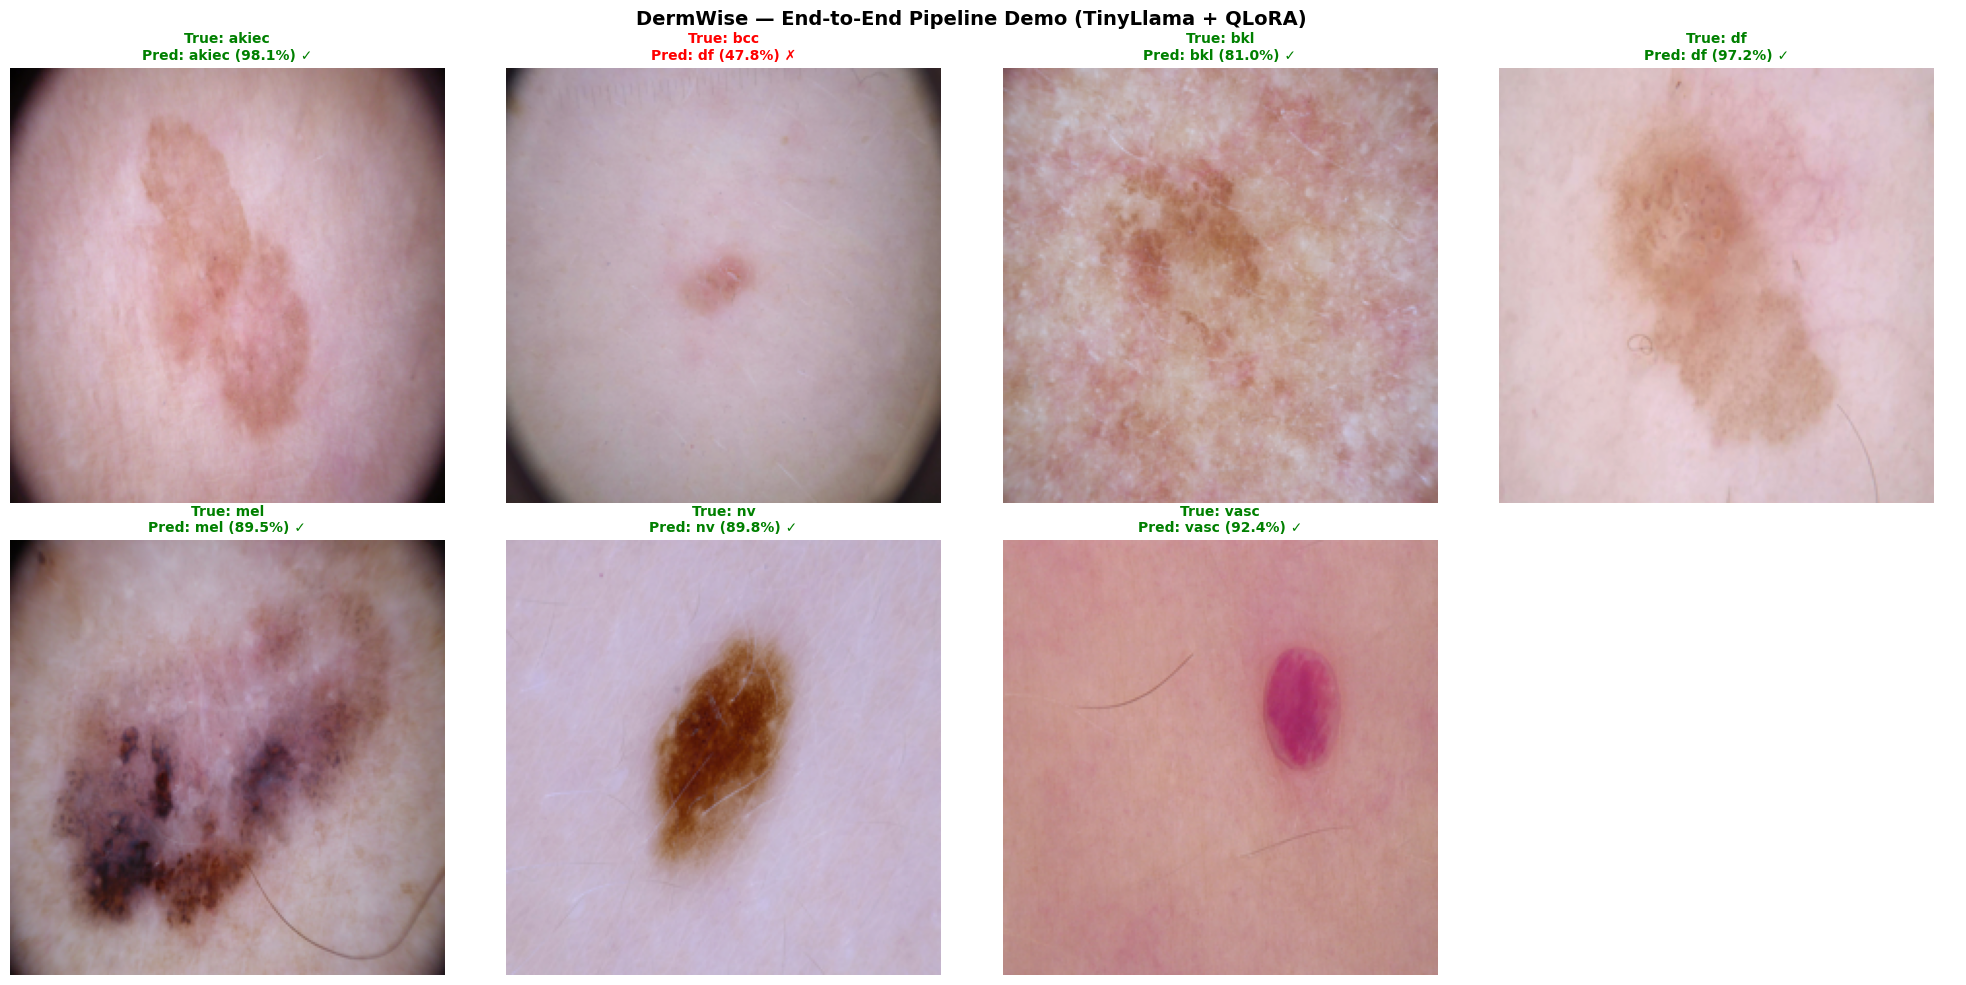


  FULL REPORT EXAMPLE

Image: ISIC_0032897
True class: akiec
Predicted: Actinic Keratosis / Bowen's Disease
Confidence: 98.1%

Top-3 predictions:
   akiec (98.14%) — Actinic Keratosis / Bowen's Disease
      df ( 0.54%) — Dermatofibroma
     bkl ( 0.41%) — Benign Keratosis (Seborrheic Keratosis / Solar Lentigo)

RAG context chunks retrieved: 10

──────────────────────────────────────────────────────────────────────
DERMWISE AI -- SKIN LESION ANALYSIS REPORT

ASSESSMENT: Actinic Keratosis / Bowen's Disease (Confidence: 98.1%)

OVERVIEW: Actinic keratosis (AK) is a precancerous skin lesion caused by cumulative ultraviolet radiation exposure. It appears on sun-exposed areas such as the face, scalp, ears, forearms, and dorsal hands. Bowen's disease and actinic keratoses typically present as rough, scaly, erythematous patches or papules measuring 2-6 mm. They may be darker in color (dark brown, black), more easily felt (than psoriasis), and generally larger than psoriasis lesions.

KEY FEA

In [11]:
# ============================================================
# CELL 7 — END-TO-END DEMO: Image → Classify → RAG → Report
# ============================================================
import os, random
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, models
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel

logger = logging.getLogger("DermWise")

# ── Config ─────────────────────────────────────────────────
CLASSIFIER_DIR = "/kaggle/working/artifacts/classifier"
ADAPTER_DIR = "/kaggle/working/artifacts/tinyllama/lora_adapter"
BASE_MODEL = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
IMG_SIZE = 224
CLASS_NAMES = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
IMG_DIRS = [
    "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1",
    "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2",
]

# ── Load classifier ───────────────────────────────────────
classifier = models.efficientnet_b0(weights=None)
classifier.classifier = torch.nn.Sequential(
    torch.nn.Dropout(0.2), torch.nn.Linear(1280, 7)
)
classifier.load_state_dict(torch.load(
    os.path.join(CLASSIFIER_DIR, "best_model.pth"),
    map_location=DEVICE
))
classifier.to(DEVICE)
classifier.eval()
logger.info("Classifier loaded.")

# ── Load TinyLlama + QLoRA adapter ────────────────────────
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR)
model_llm = AutoModelForCausalLM.from_pretrained(BASE_MODEL, quantization_config=bnb_config, device_map="auto")
model_llm = PeftModel.from_pretrained(model_llm, ADAPTER_DIR)
model_llm.eval()
logger.info("TinyLlama + QLoRA adapter loaded.")

# ── Preprocessing ─────────────────────────────────────────
preprocess = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# FULL PIPELINE FUNCTION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def dermwise_pipeline(image_path: str, use_tta: bool = True):
    img = Image.open(image_path).convert("RGB")
    img_tensor = preprocess(img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        if use_tta:
            p0 = torch.softmax(classifier(img_tensor), dim=1)
            p1 = torch.softmax(classifier(torch.flip(img_tensor, [3])), dim=1)
            p2 = torch.softmax(classifier(torch.flip(img_tensor, [2])), dim=1)
            p3 = torch.softmax(classifier(torch.flip(img_tensor, [2, 3])), dim=1)
            probs = ((p0 + p1 + p2 + p3) / 4.0).cpu().numpy()[0]
        else:
            probs = torch.softmax(classifier(img_tensor), dim=1).cpu().numpy()[0]
    
    pred_idx = probs.argmax()
    pred_class = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx])
    
    query = f"{CLASS_FULL_NAMES[pred_class]} diagnosis clinical features treatment prognosis"
    context_chunks = retrieve_context(query, top_k=5, class_filter=pred_class)
    
    report = generate_report(pred_class, confidence, context_chunks)
    
    top3_idx = probs.argsort()[::-1][:3]
    top3 = [(CLASS_NAMES[i], CLASS_FULL_NAMES[CLASS_NAMES[i]], float(probs[i])) for i in top3_idx]
    
    return {
        "image_path": image_path,
        "predicted_class": pred_class,
        "full_name": CLASS_FULL_NAMES[pred_class],
        "confidence": confidence,
        "top3": top3,
        "context_chunks": len(context_chunks),
        "report": report,
        "all_probs": {CLASS_NAMES[i]: float(probs[i]) for i in range(7)},
    }

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# DEMO
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
import pandas as pd

meta = pd.read_csv("/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv")

img_lookup = {}
for d in IMG_DIRS:
    for f in os.listdir(d):
        img_lookup[os.path.splitext(f)[0]] = os.path.join(d, f)

demo_results = []
for cls in CLASS_NAMES:
    cls_images = meta[meta['dx'] == cls]['image_id'].tolist()
    sample_id = random.choice(cls_images)
    img_path = img_lookup[sample_id]
    result = dermwise_pipeline(img_path, use_tta=True)
    demo_results.append((cls, sample_id, result))

# ── Display ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (true_cls, img_id, result) in enumerate(demo_results):
    if i >= 7:
        break
    ax = axes[i]
    img = Image.open(result["image_path"]).resize((224, 224))
    ax.imshow(img)
    pred = result["predicted_class"]
    conf = result["confidence"]
    correct = "✓" if pred == true_cls else "✗"
    color = "green" if pred == true_cls else "red"
    ax.set_title(f"True: {true_cls}\nPred: {pred} ({conf:.1%}) {correct}",
                 fontsize=10, color=color, fontweight='bold')
    ax.axis('off')

axes[7].axis('off')
plt.suptitle("DermWise — End-to-End Pipeline Demo (TinyLlama + QLoRA)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/artifacts/pipeline_demo.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Full report ────────────────────────────────────────────
print("\n" + "=" * 70)
print("  FULL REPORT EXAMPLE")
print("=" * 70)
sample = demo_results[0]
print(f"\nImage: {sample[1]}")
print(f"True class: {sample[0]}")
print(f"Predicted: {sample[2]['full_name']}")
print(f"Confidence: {sample[2]['confidence']:.1%}")
print(f"\nTop-3 predictions:")
for cls_code, cls_name, prob in sample[2]['top3']:
    print(f"  {cls_code:>6} ({prob:6.2%}) — {cls_name}")
print(f"\nRAG context chunks retrieved: {sample[2]['context_chunks']}")
print(f"\n{'─' * 70}")
print(sample[2]['report'])
print(f"{'─' * 70}")

# ── Summary ────────────────────────────────────────────────
print(f"\n{'='*70}")
print("  PIPELINE DEMO SUMMARY")
print(f"{'='*70}")
print(f"{'True':<8} {'Pred':<8} {'Conf':>8} {'Match':>6}")
print("-" * 34)
correct_count = 0
for true_cls, img_id, result in demo_results:
    pred = result['predicted_class']
    conf = result['confidence']
    match = "✓" if pred == true_cls else "✗"
    if pred == true_cls:
        correct_count += 1
    print(f"{true_cls:<8} {pred:<8} {conf:>7.1%} {match:>6}")
print("-" * 34)
print(f"Accuracy: {correct_count}/{len(demo_results)} ({correct_count/len(demo_results):.0%})")

print("\n✅ DermWise GenAI — Full pipeline with TinyLlama QLoRA operational!")

In [12]:
# ═══════════════════════════════════════════════════════════════
# EXPORT ALL MODEL ARTIFACTS FOR DEPLOYMENT
# ═══════════════════════════════════════════════════════════════
# This cell packages all 4 artifacts into a single zip file
# that you can download from Kaggle's Output tab.

import shutil
import os

# ── Define paths (adjust if your notebook saves to different locations) ──
ARTIFACTS = {
    "classifier":  "/kaggle/working/artifacts/classifier/best_model.pth",
    "faiss_index": "/kaggle/working/artifacts/rag/faiss_index.bin",
    "knowledge":   "/kaggle/working/artifacts/rag/knowledge_base.json",
    "lora_adapter": "/kaggle/working/artifacts/tinyllama/lora_adapter",  # folder
}

EXPORT_DIR = "/kaggle/working/dermassist_export"
MODELS_DIR = os.path.join(EXPORT_DIR, "models")

# ── Clean previous export ──
if os.path.exists(EXPORT_DIR):
    shutil.rmtree(EXPORT_DIR)
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Copy each artifact ──
print("Copying artifacts...\n")

# 1) Classifier weights
src = ARTIFACTS["classifier"]
if os.path.exists(src):
    shutil.copy2(src, os.path.join(MODELS_DIR, "best_model.pth"))
    size = os.path.getsize(src) / (1024 * 1024)
    print(f"  ✓ best_model.pth ({size:.1f} MB)")
else:
    print(f"  ✗ NOT FOUND: {src}")

# 2) FAISS index
src = ARTIFACTS["faiss_index"]
if os.path.exists(src):
    shutil.copy2(src, os.path.join(MODELS_DIR, "faiss_index.bin"))
    size = os.path.getsize(src) / (1024 * 1024)
    print(f"  ✓ faiss_index.bin ({size:.2f} MB)")
else:
    print(f"  ✗ NOT FOUND: {src}")

# 3) Knowledge base
src = ARTIFACTS["knowledge"]
if os.path.exists(src):
    shutil.copy2(src, os.path.join(MODELS_DIR, "knowledge_base.json"))
    size = os.path.getsize(src) / 1024
    print(f"  ✓ knowledge_base.json ({size:.1f} KB)")
else:
    print(f"  ✗ NOT FOUND: {src}")

# 4) LoRA adapter (entire folder)
src = ARTIFACTS["lora_adapter"]
dst = os.path.join(MODELS_DIR, "lora_adapter")
if os.path.exists(src):
    shutil.copytree(src, dst)
    total = sum(os.path.getsize(os.path.join(dp, f))
                for dp, _, files in os.walk(dst) for f in files)
    print(f"  ✓ lora_adapter/ ({total / (1024*1024):.1f} MB)")
    for f in os.listdir(dst):
        print(f"      └── {f}")
else:
    print(f"  ✗ NOT FOUND: {src}")

# ── Create a single zip for easy download ──
print("\nCreating zip archive...")
zip_path = shutil.make_archive(
    "/kaggle/working/dermassist_models",  # output name (no .zip)
    "zip",
    EXPORT_DIR  # directory to zip
)
zip_size = os.path.getsize(zip_path) / (1024 * 1024)
print(f"\n{'='*50}")
print(f"✓ EXPORT COMPLETE")
print(f"  Zip: {zip_path} ({zip_size:.1f} MB)")
print(f"  Contents: {os.listdir(MODELS_DIR)}")
print(f"{'='*50}")
print(f"\n→ Go to the OUTPUT tab on the right panel")
print(f"→ Click the download icon next to 'dermassist_models.zip'")
print(f"→ Extract on your machine into huggingface/models/")

Copying artifacts...

  ✓ best_model.pth (15.6 MB)
  ✓ faiss_index.bin (0.08 MB)
  ✓ knowledge_base.json (23.9 KB)
  ✓ lora_adapter/ (51.6 MB)
      └── README.md
      └── adapter_config.json
      └── chat_template.jinja
      └── adapter_model.safetensors
      └── tokenizer_config.json
      └── tokenizer.json

Creating zip archive...

✓ EXPORT COMPLETE
  Zip: /kaggle/working/dermassist_models.zip (59.5 MB)
  Contents: ['lora_adapter', 'faiss_index.bin', 'best_model.pth', 'knowledge_base.json']

→ Go to the OUTPUT tab on the right panel
→ Click the download icon next to 'dermassist_models.zip'
→ Extract on your machine into huggingface/models/
